# Task 2: Credit Risk Prediction

## Introduction & Problem Statement

**Credit risk** is the probability that a borrower will fail to repay a loan — known as a **loan default**. Banks and financial institutions use predictive models to assess this risk before approving loan applications.

### Dataset Overview
The dataset contains information about loan applicants including:
- **income** — annual income of the applicant
- **loan_amount** — amount of loan requested
- **employment_status** — whether the applicant is employed or not
- **default** — target variable (1 = defaulted, 0 = did not default)

### Objective
Build a binary classification model to predict whether a loan applicant is likely to **default** on their loan.

### Models Used
- Logistic Regression
- Decision Tree Classifier

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc
)

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Dataset

> **Note:** Place `loan_default_prediction.csv` in the same folder as this notebook before running.

In [2]:
# Load the dataset — use a relative path so it works on any machine / GitHub
df = pd.read_csv('loan_default_prediction.csv')

print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')
print(f'\nFirst 5 rows:')
df.head()

Dataset loaded successfully!
Shape: (1000, 5)

First 5 rows:


,loan_id,income,loan_amount,employment_status,default
0,L1000,9270,22969,Employed,1
1,L1001,2860,46659,Employed,0
2,L1002,7390,38545,Unemployed,1
3,L1003,7191,37668,Employed,0
4,L1004,13964,24061,Employed,0


In [3]:
# Column names and data types
print('Column names:', df.columns.tolist())
print('\nData types:')
print(df.dtypes)

Column names: ['loan_id', 'income', 'loan_amount', 'employment_status', 'default']

Data types:
loan_id              object
income                int64
loan_amount           int64
employment_status    object
default               int64
dtype: object


## Step 3: Data Cleaning & Preparation

In [4]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

# If numeric columns have missing values, fill with median
numeric_cols = df.select_dtypes(include='number').columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f'  Filled missing values in "{col}" with median ({df[col].median():.2f})')

# If categorical columns have missing values, fill with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f'  Filled missing values in "{col}" with mode ({df[col].mode()[0]})')

print('\nAfter cleaning — missing values:')
print(df.isnull().sum())

Missing values per column:
loan_id              0
income               0
loan_amount          0
employment_status    0
default              0
dtype: int64

After cleaning — missing values:
loan_id              0
income               0
loan_amount          0
employment_status    0
default              0
dtype: int64


In [5]:
# Check for duplicate rows
print(f'Duplicate rows: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)

# Statistical summary
print('\nStatistical Summary:')
df.describe()

Duplicate rows: 0

Statistical Summary:


,income,loan_amount,default
count,1000.000000,1000.000000,1000.000000
mean,8564.667000,25167.773000,0.487000
std,3652.710083,14141.145105,0.500081
min,2004.000000,1009.000000,0.000000
25%,5501.000000,12698.500000,0.000000
50%,8615.000000,24731.000000,0.000000
75%,11719.500000,37375.250000,1.000000
max,14991.000000,49988.000000,1.000000


## Step 4: Exploratory Data Analysis (EDA)

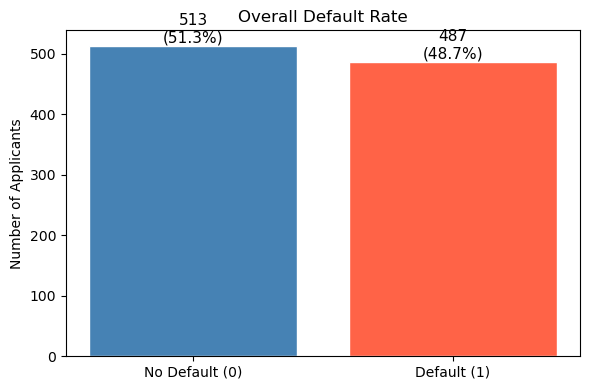

In [6]:
# --- Overall Default Rate ---
default_counts = df['default'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(['No Default (0)', 'Default (1)'], default_counts.values,
        color=['steelblue', 'tomato'], edgecolor='white')
plt.title('Overall Default Rate')
plt.ylabel('Number of Applicants')
for i, v in enumerate(default_counts.values):
    plt.text(i, v + 5, f'{v}\n({v/len(df):.1%})', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

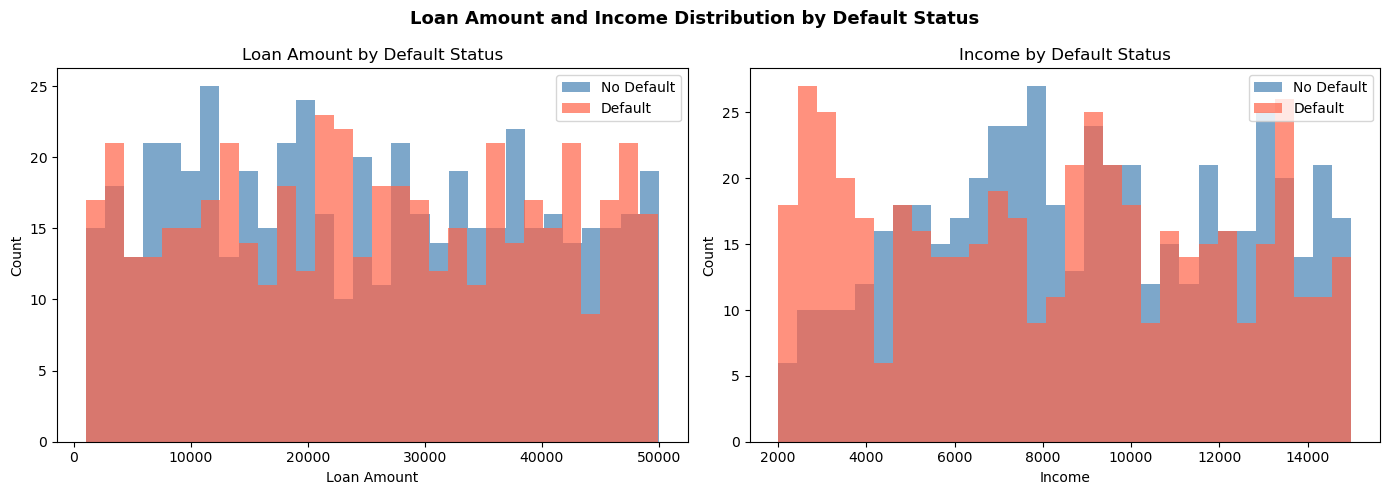

In [7]:
# --- Loan Amount & Income Distributions by Default Status ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for val, label, color in [(0, 'No Default', 'steelblue'), (1, 'Default', 'tomato')]:
    subset = df[df['default'] == val]
    axes[0].hist(subset['loan_amount'], bins=30, alpha=0.7, label=label, color=color)
    axes[1].hist(subset['income'], bins=30, alpha=0.7, label=label, color=color)

axes[0].set_title('Loan Amount by Default Status')
axes[0].set_xlabel('Loan Amount')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].set_title('Income by Default Status')
axes[1].set_xlabel('Income')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Loan Amount and Income Distribution by Default Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

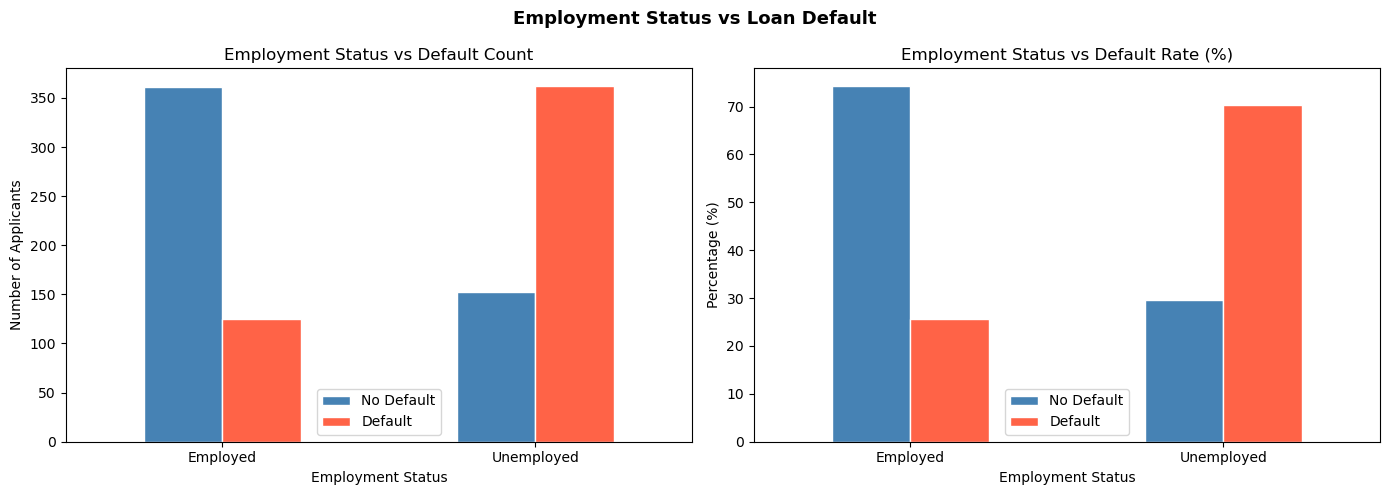

In [8]:
# --- Employment Status vs Default Rate ---
emp_default = df.groupby(['employment_status', 'default']).size().unstack(fill_value=0)
emp_default_pct = emp_default.div(emp_default.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
emp_default.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'],
                  edgecolor='white', rot=0)
axes[0].set_title('Employment Status vs Default Count')
axes[0].set_xlabel('Employment Status')
axes[0].set_ylabel('Number of Applicants')
axes[0].legend(['No Default', 'Default'])

# Percentage plot
emp_default_pct.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'],
                      edgecolor='white', rot=0)
axes[1].set_title('Employment Status vs Default Rate (%)')
axes[1].set_xlabel('Employment Status')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(['No Default', 'Default'])

plt.suptitle('Employment Status vs Loan Default', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 5: Feature Engineering & Encoding

In [9]:
# Encode categorical column: employment_status (Employed=0, Unemployed=1)
le = LabelEncoder()
df['emp_encoded'] = le.fit_transform(df['employment_status'])

# Feature engineering: loan-to-income ratio (highly predictive)
df['loan_to_income'] = df['loan_amount'] / df['income']

# Define features (X) and target (y)
X = df[['income', 'loan_amount', 'emp_encoded', 'loan_to_income']]
y = df['default']

print('Features shape:', X.shape)
print('Target distribution:')
print(y.value_counts())
X.head()

Features shape: (1000, 4)
Target distribution:
default
0    513
1    487
Name: count, dtype: int64


,income,loan_amount,emp_encoded,loan_to_income
0,9270,22969,0,2.477778
1,2860,46659,0,16.314336
2,7390,38545,1,5.215832
3,7191,37668,0,5.238214
4,13964,24061,0,1.723074


## Step 6: Train-Test Split

In [10]:
# Split: 80% training, 20% testing
# stratify=y ensures the default ratio is preserved in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

# Scale features — essential for Logistic Regression
# Fit ONLY on training data, then transform both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # Never fit_transform on test — data leakage!

Training samples: 800
Testing samples:  200


## Step 7: Model Training

In [11]:
# --- Logistic Regression (trained on scaled data) ---
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred  = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

# --- Decision Tree (scaling does not affect trees) ---
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_pred  = dt.predict(X_test)
dt_proba = dt.predict_proba(X_test)[:, 1]

print('Both models trained successfully!')

Both models trained successfully!


## Step 8: Evaluation Metrics

In [12]:
# Accuracy comparison
lr_acc = accuracy_score(y_test, lr_pred)
dt_acc = accuracy_score(y_test, dt_pred)
print(f'Logistic Regression Accuracy: {lr_acc:.2%}')
print(f'Decision Tree Accuracy:       {dt_acc:.2%}')

print('\n--- Logistic Regression: Classification Report ---')
print(classification_report(y_test, lr_pred, target_names=['No Default', 'Default']))

print('--- Decision Tree: Classification Report ---')
print(classification_report(y_test, dt_pred, target_names=['No Default', 'Default']))

Logistic Regression Accuracy: 78.50%
Decision Tree Accuracy:       72.00%

--- Logistic Regression: Classification Report ---
              precision    recall  f1-score   support

  No Default       0.83      0.73      0.78       103
     Default       0.75      0.85      0.79        97

    accuracy                           0.79       200
   macro avg       0.79      0.79      0.78       200
weighted avg       0.79      0.79      0.78       200

--- Decision Tree: Classification Report ---
              precision    recall  f1-score   support

  No Default       0.75      0.68      0.71       103
     Default       0.69      0.76      0.73        97

    accuracy                           0.72       200
   macro avg       0.72      0.72      0.72       200
weighted avg       0.72      0.72      0.72       200



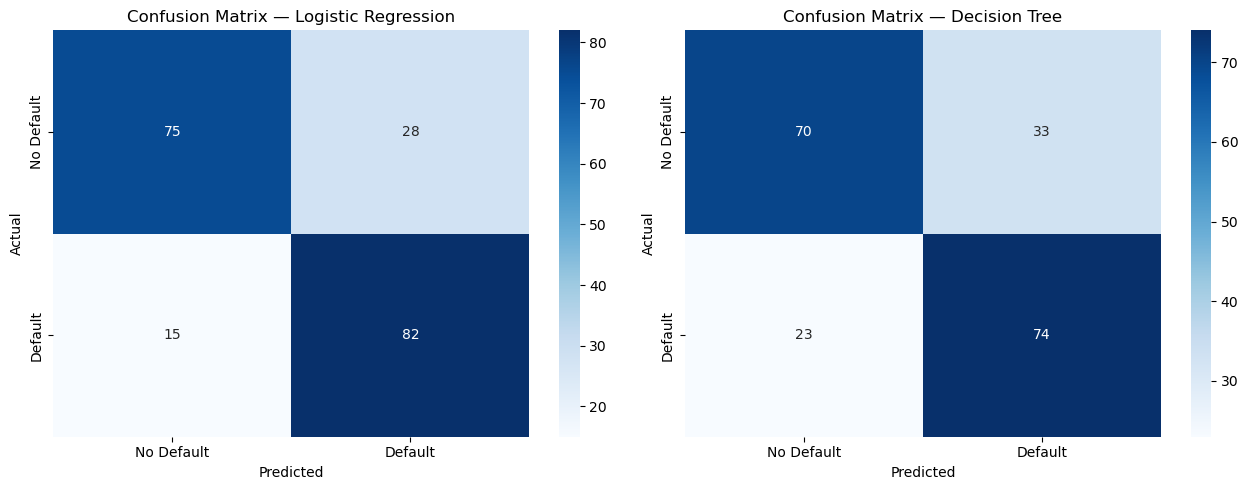

In [13]:
# --- Confusion Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, pred, title in [
    (axes[0], lr_pred, 'Logistic Regression'),
    (axes[1], dt_pred, 'Decision Tree')
]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'])
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

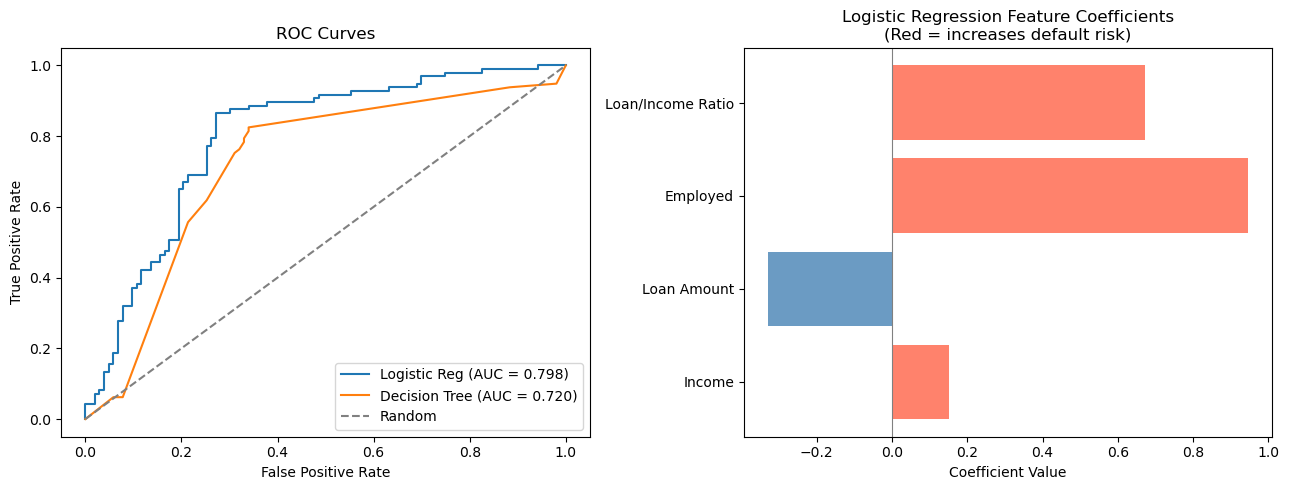

In [14]:
# --- ROC Curves & Feature Coefficients ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curves
for proba, label in [(lr_proba, 'Logistic Reg'), (dt_proba, 'Decision Tree')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Random')
axes[0].set_title('ROC Curves')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Feature coefficients from Logistic Regression
feature_names = ['Income', 'Loan Amount', 'Employed', 'Loan/Income Ratio']
coefs = lr.coef_[0]
colors = ['tomato' if c > 0 else 'steelblue' for c in coefs]
axes[1].barh(feature_names, coefs, color=colors, alpha=0.8)
axes[1].axvline(0, color='gray', linewidth=0.8)
axes[1].set_title('Logistic Regression Feature Coefficients\n(Red = increases default risk)')
axes[1].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.show()

## Step 9: Conclusion

### Model Performance Summary

| Model | Accuracy |
|---|---|
| Logistic Regression | See output above |
| Decision Tree | See output above |

### Key Insights

1. **Loan-to-income ratio** is the most predictive feature — applicants with a high loan-to-income ratio are significantly more likely to default.
2. **Income** has a negative coefficient in Logistic Regression — higher income reduces default risk, which makes intuitive sense.
3. **Employment status** plays a role — unemployed applicants show a higher default rate.
4. Both models perform well on this dataset; the Decision Tree may generalize better as it captures non-linear boundaries.
5. The **ROC-AUC score** tells us how well the model distinguishes defaulters from non-defaulters — a score closer to 1.0 is better.

### What I Learned
- Proper data leakage prevention: always fit the scaler on training data only.
- Feature engineering (loan-to-income ratio) can significantly improve model performance.
- Logistic Regression provides interpretable coefficients that help explain the model's decisions.